# Clustering Application (Album Indexing)

In [17]:
import os
import sys
import yaml
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

In [ ]:
import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [4]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)["reid_project"]

In [14]:
from src.utils.clustering import perform_clustering, evaluate_clusters, visualize_cluster_accuracy, calculate_cluster_purity
from src.utils.evaluator import evaluate, compute_distmat, extract_features
from src.dataloaders.market_dataset import MarketDataset
from src.models.resnet50 import ResNet50

## 1. Clustering pipeline

Extract embeddings from all person crops, cluster with DBSCAN or Agglomerative Clustering on cosine distance.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50(
    num_classes=config['market1501']['num_classes'], 
    feature_dim=config["models"]["resnet50"]["feature_dim"],
    last_stride=config["models"]["resnet50"]["last_stride"]
)
model_path = "results/exp_resnet50_v1/resnet50_reid_epoch_1.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

ResNet50(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64

In [7]:
transform = transforms.Compose([
    transforms.Resize(config['market1501']['img_size'], 
                      interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
gallery_ds = MarketDataset(root_dir=config['market1501']['root_dir'], subset='test', transform=transform)
gallery_loader = DataLoader(gallery_ds, batch_size=32, shuffle=False)

In [9]:
g_feat, g_pids, g_camids = extract_features(model, gallery_loader, device)
features = g_feat.cpu().numpy()

Extraction: 100%|██████████| 410/410 [18:14<00:00,  2.67s/it]  


In [10]:
pred_labels = perform_clustering(features, eps=0.35)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.843908..1.83

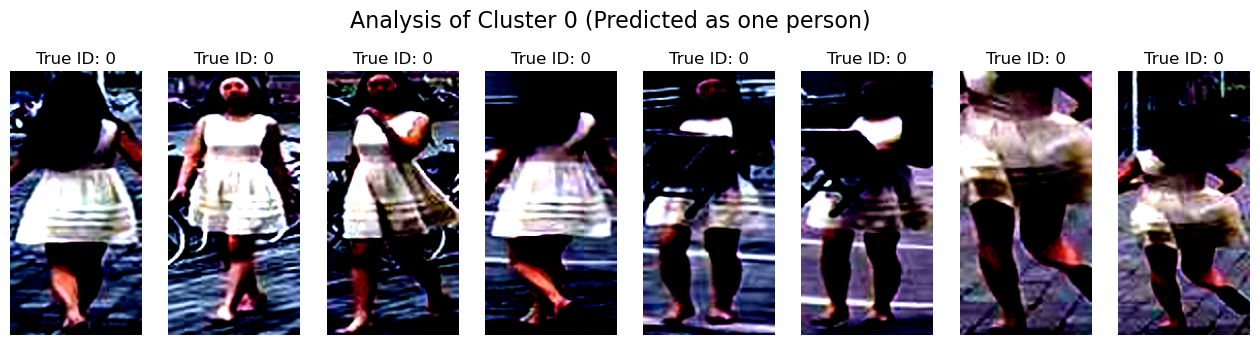

In [12]:
visualize_cluster_accuracy(0, pred_labels, gallery_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.64].


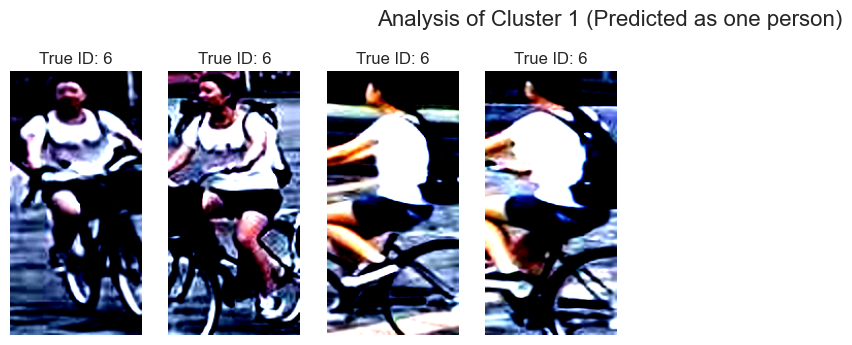

In [28]:
visualize_cluster_accuracy(1, pred_labels, gallery_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..2.343704].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.2184873].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7411594..2.3760502].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812.

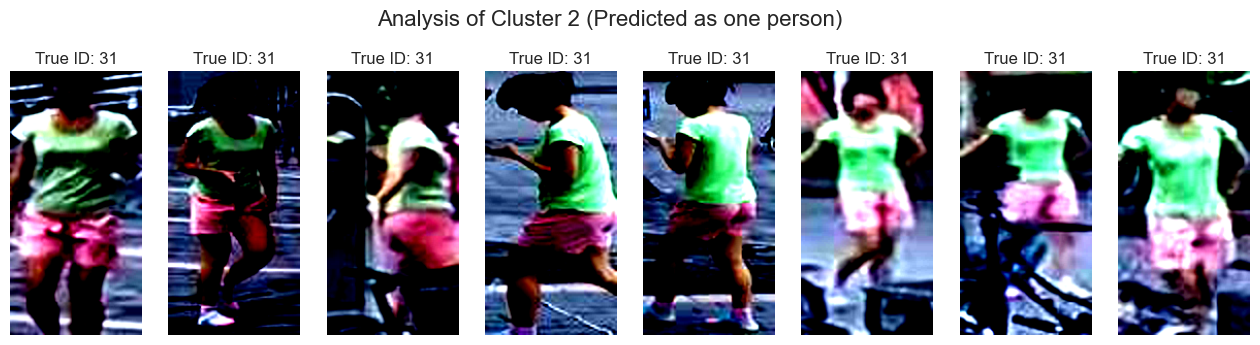

In [31]:
visualize_cluster_accuracy(2, pred_labels, gallery_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9306722..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.64].


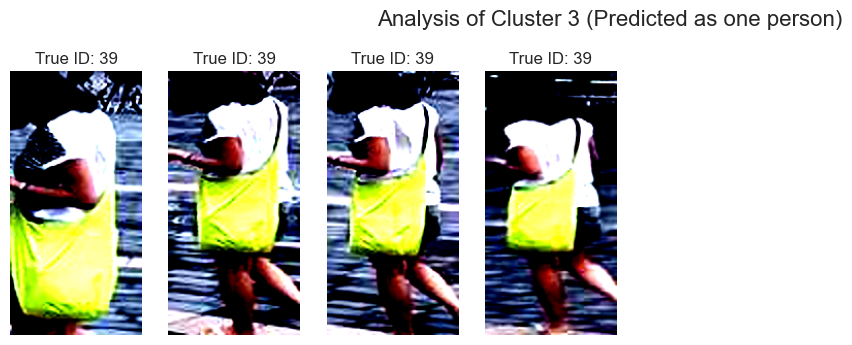

In [32]:
visualize_cluster_accuracy(3, pred_labels, gallery_ds)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8256302..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7731092..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping i

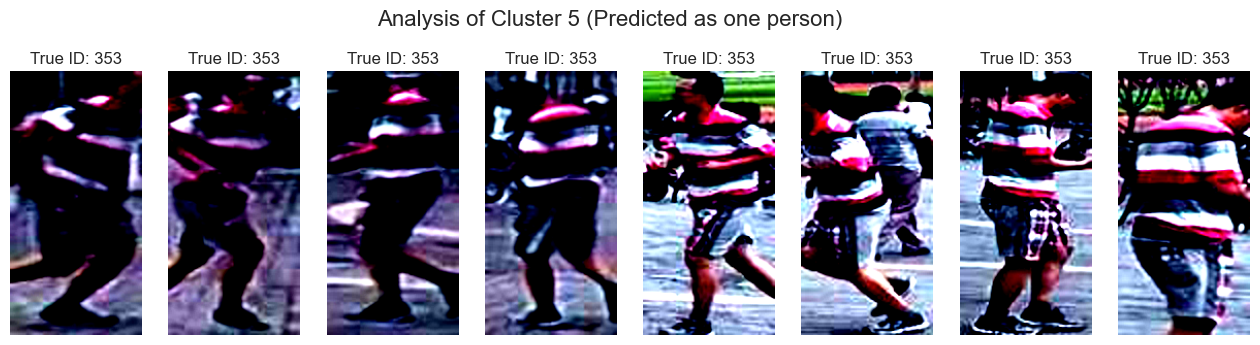

In [33]:
visualize_cluster_accuracy(5, pred_labels, gallery_ds)

In [15]:
avg_purity = calculate_cluster_purity(g_pids, pred_labels)
print(f"Albums average purity: {avg_purity:.2%}")

Albums average purity: 88.95%


## 2. Cluster Evaluation & Threshold Sensitivity

Evaluation with NMI, ARI, Purity (using ground-truth labels for validation only).

In [23]:
eps_range = np.linspace(0.1, 0.7, 15)
results = []

for e in tqdm(eps_range, desc="Clustering Sensitivity Study"):
    labels = perform_clustering(features, eps=e)
    metrics = evaluate_clusters(g_pids, labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    results.append({
        'eps': e, 
        'NMI': metrics['NMI'], 
        'ARI': metrics['ARI'],
        'clusters': n_clusters
    })

df_sens = pd.DataFrame(results)

Clustering Sensitivity Study: 100%|██████████| 15/15 [00:50<00:00,  3.37s/it]


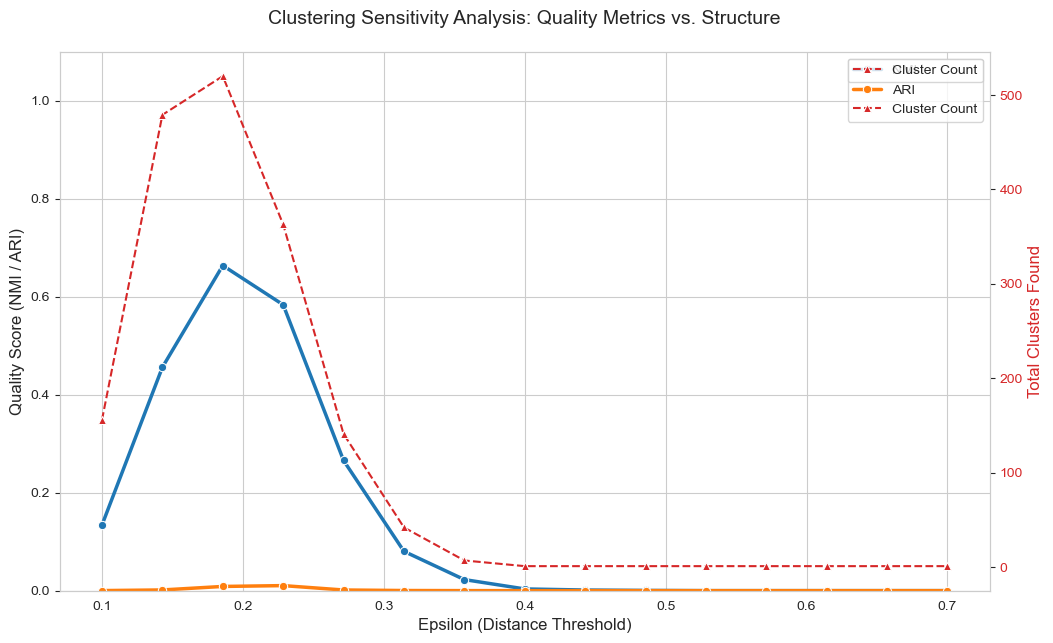

In [25]:
df_metrics = df_sens.melt(id_vars=['eps', 'clusters'], 
                          value_vars=['NMI', 'ARI'], 
                          var_name='Metric', 
                          value_name='Score')

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax1 = sns.lineplot(data=df_metrics, x='eps', y='Score', hue='Metric', marker='o', linewidth=2.5)

ax2 = ax1.twinx()
sns.lineplot(data=df_sens, x='eps', y='clusters', color='tab:red', marker='^', linestyle='--', ax=ax2, label='Cluster Count')

ax1.set_xlabel('Epsilon (Distance Threshold)', fontsize=12)
ax1.set_ylabel('Quality Score (NMI / ARI)', fontsize=12)
ax1.set_ylim(0, 1.1)

ax2.set_ylabel('Total Clusters Found', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title("Clustering Sensitivity Analysis: Quality Metrics vs. Structure", fontsize=14, pad=20)
plt.show()

## 3. Album Demo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.1171243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8256302..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9656862..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.64].
Clipping input d

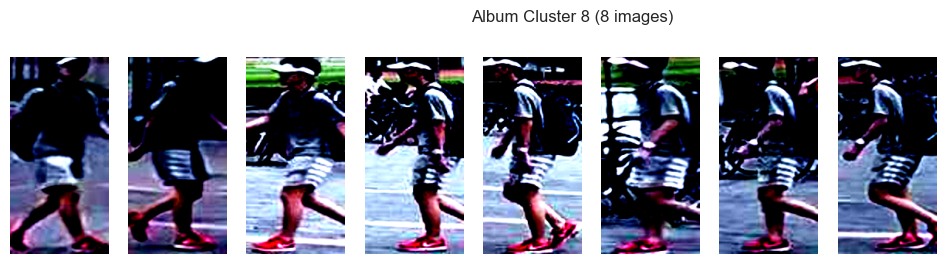

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.3785625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input

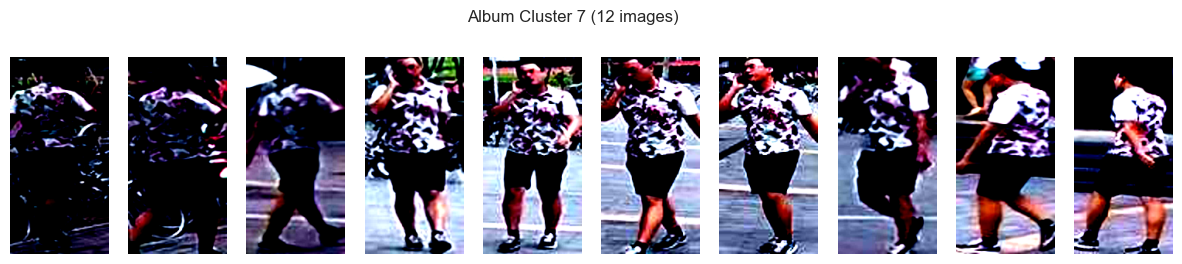

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8256302..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7731092..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6897851..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping i

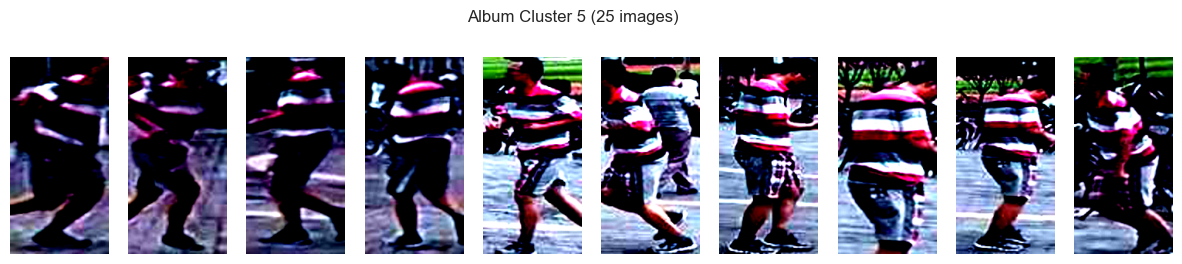

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..2.343704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.2184873].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7411594..2.3760502].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..

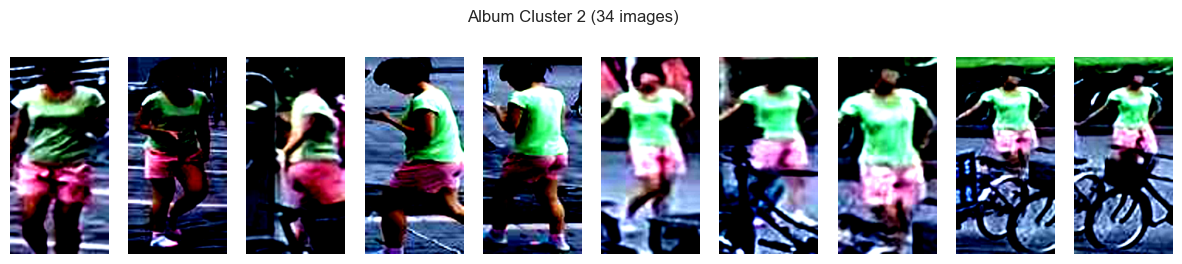

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.843908..1.83

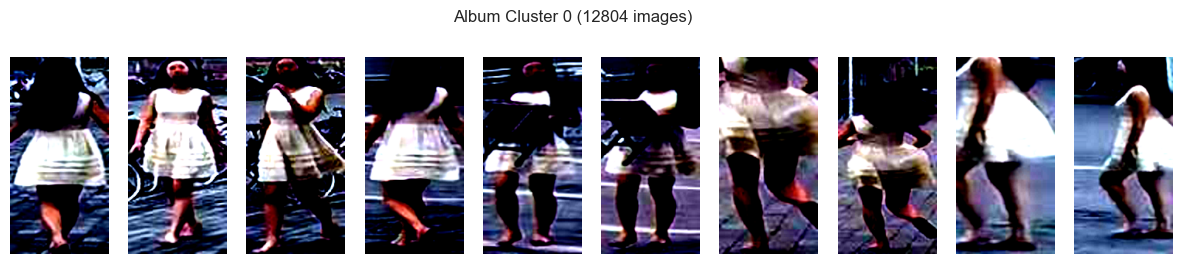

In [34]:
def display_album(cluster_id, pred_labels, dataset, max_imgs=10):
    indices = np.where(pred_labels == cluster_id)[0]
    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(indices[:max_imgs]):
        img, _, _ = dataset[idx]
        img = img.permute(1, 2, 0).numpy()
        plt.subplot(1, max_imgs, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f"Album Cluster {cluster_id} ({len(indices)} images)")
    plt.show()

unique_clusters, counts = np.unique(pred_labels[pred_labels != -1], return_counts=True)
for c in unique_clusters[np.argsort(counts)[-5:]]:
    display_album(c, pred_labels, gallery_ds)